In [1]:
import os
import json
import numpy as np
import pandas as pd
import warnings
import sys
import importlib.util
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import optuna
import shap  # SHAP summary plot용

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 프로젝트 루트 디렉토리 설정
current_dir = os.getcwd()
if '03_배포용' in current_dir:
    project_root = current_dir.split('03_배포용')[0]
else:
    project_root = current_dir
    while not os.path.exists(os.path.join(project_root, '03_배포용')):
        parent = os.path.dirname(project_root)
        if parent == project_root:
            project_root = os.getcwd()
            break
        project_root = parent

# 프로젝트 루트로 작업 디렉토리 변경
os.chdir(project_root)

# 전처리 함수 모듈 import (파일명이 숫자로 시작하므로 importlib 사용)
module_path = os.path.join(project_root, '03_배포용/02_model/00_prepare_for_LGBM.py')
spec = importlib.util.spec_from_file_location("prepare_for_LGBM", module_path)
prepare_for_LGBM = importlib.util.module_from_spec(spec)
spec.loader.exec_module(prepare_for_LGBM)

# 함수 import
drop_columns_for_lgbm = prepare_for_LGBM.drop_columns_for_lgbm
categorize_displacement = prepare_for_LGBM.categorize_displacement
convert_binned_features_to_ordinal = prepare_for_LGBM.convert_binned_features_to_ordinal
convert_to_categorical = prepare_for_LGBM.convert_to_categorical
remove_nan_rows_in_binned_features = prepare_for_LGBM.remove_nan_rows_in_binned_features

print("✓ 전처리 함수 모듈 로드 완료")

✓ 전처리 함수 모듈 로드 완료


In [2]:
# ============================================================
# 1. 데이터 로드 (클러스터별 Train/Test)
# ============================================================
print("="*70)
print("클러스터별 데이터 로드 및 전처리")
print("="*70)

# 데이터 경로 설정 (프로젝트 루트 기준)
train_file = os.path.join(project_root, '03_배포용/00_data/03_result/kmodes_model/df_train_cluster.csv')
test_file = os.path.join(project_root, '03_배포용/00_data/03_result/kmodes_model/df_test_cluster.csv')
results_dir = os.path.join(project_root, '03_배포용/00_data/03_result/lgbm_models')
os.makedirs(results_dir, exist_ok=True)

print(f"Train 파일 경로: {train_file}")
print(f"파일 존재 여부: {os.path.exists(train_file)}")
print(f"Test 파일 경로: {test_file}")
print(f"파일 존재 여부: {os.path.exists(test_file)}")

# 전체 데이터 로드
print("\n전체 Train/Test 데이터 로드 중...")
df_train_all = pd.read_csv(train_file, low_memory=False)
df_test_all = pd.read_csv(test_file, low_memory=False)
print(f"✓ Train: {len(df_train_all):,}건")
print(f"✓ Test: {len(df_test_all):,}건")

# 클러스터 번호 (0~5)
cluster_numbers = sorted(df_train_all['cluster'].unique()) if 'cluster' in df_train_all.columns else [0, 1, 2, 3, 4, 5]
print(f"\n클러스터 번호: {cluster_numbers}")

# 클러스터별 데이터 분리
train_data = {}
test_data = {}

for cluster_num in cluster_numbers:
    train_data[cluster_num] = df_train_all[df_train_all['cluster'] == cluster_num].copy()
    test_data[cluster_num] = df_test_all[df_test_all['cluster'] == cluster_num].copy()
    print(f"\n✓ Cluster {cluster_num} 분리 완료")
    print(f"  - Train: {len(train_data[cluster_num]):,}건")
    print(f"  - Test: {len(test_data[cluster_num]):,}건")

print(f"\n총 {len(train_data)}개 클러스터 로드 완료")

클러스터별 데이터 로드 및 전처리
Train 파일 경로: /Users/dan/Desktop/코오롱_프로젝트/01_예측/03_배포용/00_data/03_result/kmodes_model/df_train_cluster.csv
파일 존재 여부: True
Test 파일 경로: /Users/dan/Desktop/코오롱_프로젝트/01_예측/03_배포용/00_data/03_result/kmodes_model/df_test_cluster.csv
파일 존재 여부: True

전체 Train/Test 데이터 로드 중...


✓ Train: 145,799건
✓ Test: 11,203건

클러스터 번호: [0, 1, 2, 3, 4, 5]

✓ Cluster 0 분리 완료
  - Train: 55,187건
  - Test: 4,393건

✓ Cluster 1 분리 완료
  - Train: 21,609건
  - Test: 1,654건

✓ Cluster 2 분리 완료
  - Train: 18,431건
  - Test: 1,266건

✓ Cluster 3 분리 완료
  - Train: 13,082건
  - Test: 983건

✓ Cluster 4 분리 완료
  - Train: 13,752건
  - Test: 921건

✓ Cluster 5 분리 완료
  - Train: 23,738건
  - Test: 1,986건

총 6개 클러스터 로드 완료


In [3]:
# ============================================================
# 2. 클러스터별 전처리 적용
# ============================================================
print("\n" + "="*70)
print("클러스터별 전처리 적용")
print("="*70)

# 전처리된 데이터 저장용
train_processed = {}
test_processed = {}

for cluster_num in cluster_numbers:
    if cluster_num not in train_data:
        continue
    
    print(f"\n{'='*70}")
    print(f"Cluster {cluster_num} 전처리 시작")
    print(f"{'='*70}")
    
    # Train 데이터 전처리
    df_train = train_data[cluster_num].copy()
    print(f"\n[Train] 초기 데이터: {len(df_train):,}건, {len(df_train.columns)}개 컬럼")
    
    # 1) 불필요한 컬럼 제거
    print("\n[1단계] 불필요한 컬럼 제거...")
    df_train = drop_columns_for_lgbm(df_train)
    
    # 2) 등급코드 빈도가 10개 이하인 행 제거 (학습 데이터 품질 향상)
    print("\n[2단계] 등급코드 빈도가 10개 이하인 행 제거...")
    if '등급코드' in df_train.columns:
        before_count = len(df_train)
        
        # 등급코드별 빈도 계산
        grade_counts = df_train['등급코드'].value_counts()
        
        # 빈도가 10개 이하인 등급코드 찾기
        low_freq_grades = grade_counts[grade_counts <= 10].index.tolist()
        low_freq_count = grade_counts[grade_counts <= 10].sum()
        
        if len(low_freq_grades) > 0:
            print(f"  ⚠ 빈도가 10개 이하인 등급코드: {len(low_freq_grades):,}개")
            print(f"  → 제거될 행 수: {low_freq_count:,}건")
            
            # 빈도가 10개 이하인 등급코드의 행 제거
            df_train = df_train[~df_train['등급코드'].isin(low_freq_grades)].copy()
            
            removed_count = before_count - len(df_train)
            removed_pct = (removed_count / before_count) * 100 if before_count > 0 else 0
            
            print(f"  → 제거 완료: {removed_count:,}건 ({removed_pct:.2f}%)")
            print(f"  → 제거 후: {len(df_train):,}건")
            print(f"  ✓ 이유: 등급코드 빈도가 너무 낮으면 학습이 제대로 되지 않을 수 있음")
        else:
            print(f"  ✓ 빈도가 10개 이하인 등급코드가 없습니다.")
    else:
        print("  ⚠ '등급코드' 컬럼이 없어 건너뜁니다.")
    
    # 3) 배기량을 순서형 카테고리로 변환 (배기량 컬럼이 있는 경우)
    if '배기량' in df_train.columns:
        print("\n[3단계] 배기량을 순서형 카테고리로 변환...")
        df_train = categorize_displacement(df_train, disp_col='배기량')
    else:
        print("\n[3단계] 배기량 컬럼이 없어 건너뜁니다.")
    
    # 4) 구간 컬럼들을 순서형으로 변환
    print("\n[4단계] 구간 컬럼들을 순서형 카테고리로 변환...")
    df_train = convert_binned_features_to_ordinal(df_train)
    
    # 5) 명목형 컬럼들을 category로 변환 (LightGBM 호환성)
    print("\n[5단계] 명목형 컬럼을 category로 변환...")
    df_train = convert_to_categorical(df_train, verbose=True)
    
    # 6) 구간 피처 NaN 행 제거 (unseen 등급코드 처리)
    print("\n[6단계] 구간 피처 NaN 행 제거...")
    df_train = remove_nan_rows_in_binned_features(
        df_train,
        check_cols=['판매속도지수_등급코드_구간', '빈도_등급코드_구간'],
        verbose=True
    )
    
    train_processed[cluster_num] = df_train
    print(f"\n✓ Train 전처리 완료: {len(df_train):,}건, {len(df_train.columns)}개 컬럼")
    
    # Test 데이터 전처리
    # 주의: Test는 Train에서 제거된 등급코드와 Train에 없는 등급코드로 인한 NaN만 제거
    df_test = test_data[cluster_num].copy()
    print(f"\n[Test] 초기 데이터: {len(df_test):,}건, {len(df_test.columns)}개 컬럼")
    
    # 1) 불필요한 컬럼 제거
    print("\n[1단계] 불필요한 컬럼 제거...")
    df_test = drop_columns_for_lgbm(df_test)
    
    # 2) Train에서 제거된 등급코드(빈도 10개 이하)가 Test에 있는 경우 제거
    print("\n[2단계] Train에서 제거된 등급코드(빈도 10개 이하)가 Test에 있는 경우 제거...")
    if '등급코드' in df_test.columns and '등급코드' in df_train.columns:
        # Train에서 유지된 등급코드만 사용 (빈도 10개 이하 제거 후)
        train_valid_grades = set(df_train['등급코드'].unique())
        test_grades = set(df_test['등급코드'].unique())
        removed_grades_in_test = test_grades - train_valid_grades
        
        if len(removed_grades_in_test) > 0:
            before_test_count = len(df_test)
            # Train에서 제거된 등급코드의 행 제거
            df_test = df_test[df_test['등급코드'].isin(train_valid_grades)].copy()
            removed_test_count = before_test_count - len(df_test)
            removed_test_pct = (removed_test_count / before_test_count) * 100 if before_test_count > 0 else 0
            
            print(f"  ⚠ Train에서 제거된 등급코드가 Test에 있음: {len(removed_grades_in_test):,}개")
            print(f"  → 제거된 행: {removed_test_count:,}건 ({removed_test_pct:.2f}%)")
            print(f"  → 제거 후: {len(df_test):,}건")
        else:
            print(f"  ✓ Train에서 제거된 등급코드가 Test에 없습니다.")
    else:
        print("  ⚠ '등급코드' 컬럼이 없어 건너뜁니다.")
    
    # 3) 배기량을 순서형 카테고리로 변환
    if '배기량' in df_test.columns:
        print("\n[3단계] 배기량을 순서형 카테고리로 변환...")
        df_test = categorize_displacement(df_test, disp_col='배기량')
    else:
        print("\n[3단계] 배기량 컬럼이 없어 건너뜁니다.")
    
    # 4) 구간 컬럼들을 순서형으로 변환
    print("\n[4단계] 구간 컬럼들을 순서형 카테고리로 변환...")
    df_test = convert_binned_features_to_ordinal(df_test)
    
    # 5) 명목형 컬럼들을 category로 변환 (LightGBM 호환성)
    print("\n[5단계] 명목형 컬럼을 category로 변환...")
    df_test = convert_to_categorical(df_test, verbose=True)
    
    # 6) 구간 피처 NaN 행 제거 (Train에 없는 등급코드로 인한 NaN 처리)
    print("\n[6단계] 구간 피처 NaN 행 제거 (Train에 없는 등급코드 처리)...")
    df_test = remove_nan_rows_in_binned_features(
        df_test,
        check_cols=['판매속도지수_등급코드_구간', '빈도_등급코드_구간'],
        verbose=True
    )
    
    test_processed[cluster_num] = df_test
    print(f"\n✓ Test 전처리 완료: {len(df_test):,}건, {len(df_test.columns)}개 컬럼")
    
    print(f"\n{'='*70}")
    print(f"Cluster {cluster_num} 전처리 완료")
    print(f"{'='*70}")

print("\n" + "="*70)
print("모든 클러스터 전처리 완료")
print("="*70)



클러스터별 전처리 적용

Cluster 0 전처리 시작

[Train] 초기 데이터: 55,187건, 48개 컬럼

[1단계] 불필요한 컬럼 제거...
✓ 제거된 컬럼: 16개
  - 제조사, 모델, 등급, 세부등급, 연월식, 배기량, 교환부위, 판금부위, 최초 광고 등록일, 최초 광고가, 판매신고일, has_planned_next_gen, log_km_per_month, mileage_ratio, sale_month, sale_week

[2단계] 등급코드 빈도가 10개 이하인 행 제거...
  ⚠ 빈도가 10개 이하인 등급코드: 639개
  → 제거될 행 수: 2,452건
  → 제거 완료: 2,452건 (4.44%)
  → 제거 후: 52,735건
  ✓ 이유: 등급코드 빈도가 너무 낮으면 학습이 제대로 되지 않을 수 있음

[3단계] 배기량 컬럼이 없어 건너뜁니다.

[4단계] 구간 컬럼들을 순서형 카테고리로 변환...
✓ 배기량_구간 처리 완료:
  - 전기/수소차 플래그(is_ev_h2) 생성: 4,574건 (전체 52,735건 중)
  - 배기량_구간: 0cc 제외, 나머지 6개 구간을 순서형으로 변환
  - 전기차 행은 유지됨: is_ev_h2=1, 배기량_구간=NaN
✓ 신차가격_구간을 순서형 카테고리로 변환 완료
✓ 빈도_등급코드_구간을 순서형 카테고리로 변환 완료
✓ 판매속도지수_등급코드_구간을 순서형 카테고리로 변환 완료

[5단계] 명목형 컬럼을 category로 변환...
  ✓ 8개 object 컬럼 변환: 대표차종명, 세부등급코드, 색상, 차종, 연료, 용도변경이력, 사고유무, 단순수리
  ✓ 국산외제차를 category로 변환 완료
  ✓ 4개 코드 컬럼을 category로 변환: 제조사코드, 모델코드, 등급코드, 세부등급코드
  ✓ is_ev_h2를 category로 변환 완료

[6단계] 구간 피처 NaN 행 제거...
  ✓ 구간 피처 NaN 없음

✓ Train 전처리 완료: 52,735건, 33개 컬럼

[Test] 초

In [4]:
# ============================================================
# 3. 전처리 후 컬럼 타입 정리
# ============================================================
print("\n" + "="*70)
print("전처리 후 컬럼 타입 정리")
print("="*70)

# 첫 번째 클러스터의 데이터를 기준으로 타입 확인
if cluster_numbers and cluster_numbers[0] in train_processed:
    sample_cluster = cluster_numbers[0]
    df_sample = train_processed[sample_cluster]
    
    print(f"\n[Cluster {sample_cluster} 기준 컬럼 타입 분석]")
    print(f"총 컬럼 수: {len(df_sample.columns)}개\n")
    
    # 컬럼 타입별 분류
    categorical_cols = []  # 명목형 카테고리
    ordinal_cols = []      # 순서형 카테고리
    numeric_cols = []      # 수치형
    
    for col in df_sample.columns:
        if col in ['감가율', 'cluster']:  # 타겟/메타 컬럼 제외
            continue
            
        dtype = df_sample[col].dtype
        
        # 순서형 카테고리 확인
        if hasattr(df_sample[col], 'cat') and df_sample[col].cat.ordered:
            ordinal_cols.append(col)
        # 명목형 카테고리 확인
        elif dtype == 'category' or (hasattr(df_sample[col], 'cat') and not df_sample[col].cat.ordered):
            categorical_cols.append(col)
        # 수치형
        elif pd.api.types.is_numeric_dtype(dtype):
            numeric_cols.append(col)
        else:
            # 기타 (object 등)
            categorical_cols.append(col)
    
    # 결과 출력
    print(f"📊 순서형 카테고리 (Ordinal Category): {len(ordinal_cols)}개")
    if ordinal_cols:
        for col in ordinal_cols:
            n_unique = df_sample[col].nunique()
            print(f"  - {col} ({n_unique}개 카테고리)")
    else:
        print("  (없음)")
    
    print(f"\n📋 명목형 카테고리 (Nominal Category): {len(categorical_cols)}개")
    if categorical_cols:
        for col in categorical_cols:
            n_unique = df_sample[col].nunique()
            print(f"  - {col} ({n_unique}개 카테고리)")
    else:
        print("  (없음)")
    
    print(f"\n🔢 수치형 (Numeric): {len(numeric_cols)}개")
    if numeric_cols:
        for col in numeric_cols:
            dtype = df_sample[col].dtype
            print(f"  - {col} ({dtype})")
    else:
        print("  (없음)")
    
    print(f"\n✓ 총 {len(ordinal_cols) + len(categorical_cols) + len(numeric_cols)}개 피처 컬럼")
    
    # 클러스터별 요약
    print("\n" + "="*70)
    print("클러스터별 컬럼 타입 요약")
    print("="*70)
    
    for cluster_num in cluster_numbers:
        if cluster_num not in train_processed:
            continue
        
        df_cluster = train_processed[cluster_num]
        ordinal_count = sum(1 for col in df_cluster.columns 
                           if hasattr(df_cluster[col], 'cat') and df_cluster[col].cat.ordered)
        category_count = sum(1 for col in df_cluster.columns 
                            if df_cluster[col].dtype == 'category' or 
                            (hasattr(df_cluster[col], 'cat') and not df_cluster[col].cat.ordered))
        numeric_count = sum(1 for col in df_cluster.columns 
                           if pd.api.types.is_numeric_dtype(df_cluster[col].dtype) and 
                           col not in ['감가율', 'cluster'])
        
        print(f"\nCluster {cluster_num}:")
        print(f"  - 순서형 카테고리: {ordinal_count}개")
        print(f"  - 명목형 카테고리: {category_count}개")
        print(f"  - 수치형: {numeric_count}개")
        print(f"  - 총 피처: {ordinal_count + category_count + numeric_count}개")
else:
    print("⚠ 전처리된 데이터가 없습니다.")



전처리 후 컬럼 타입 정리

[Cluster 0 기준 컬럼 타입 분석]
총 컬럼 수: 33개

📊 순서형 카테고리 (Ordinal Category): 4개
  - 배기량_구간 (5개 카테고리)
  - 신차가격_구간 (7개 카테고리)
  - 판매속도지수_등급코드_구간 (4개 카테고리)
  - 빈도_등급코드_구간 (5개 카테고리)

📋 명목형 카테고리 (Nominal Category): 13개
  - 대표차종명 (161개 카테고리)
  - 제조사코드 (29개 카테고리)
  - 모델코드 (246개 카테고리)
  - 등급코드 (606개 카테고리)
  - 세부등급코드 (557개 카테고리)
  - 색상 (31개 카테고리)
  - 차종 (10개 카테고리)
  - 연료 (6개 카테고리)
  - 용도변경이력 (2개 카테고리)
  - 사고유무 (2개 카테고리)
  - 단순수리 (2개 카테고리)
  - 국산외제차 (2개 카테고리)
  - is_ev_h2 (2개 카테고리)

🔢 수치형 (Numeric): 15개
  - 신차가격(선택옵션포함) (int64)
  - 주행거리 (float64)
  - 판매신고가 (int64)
  - gen_norm (float64)
  - 판매기준금리 (float64)
  - 사고_심각도 (int64)
  - 차나이_월 (int64)
  - 차나이_년 (int64)
  - km_per_month (float64)
  - month_sin (float64)
  - month_cos (float64)
  - week_sin (float64)
  - week_cos (float64)
  - 판매속도지수_등급코드 (float64)
  - 빈도_등급코드 (float64)

✓ 총 32개 피처 컬럼

클러스터별 컬럼 타입 요약

Cluster 0:
  - 순서형 카테고리: 4개
  - 명목형 카테고리: 17개
  - 수치형: 15개
  - 총 피처: 36개

Cluster 1:
  - 순서형 카테고리: 4개
  - 명목형 카테고리: 17개
  - 수치형: 15개

In [5]:
# ============================================================
# 3. K-Fold 설정 (Train 데이터 기준으로 5개)
# ============================================================
print("\n" + "="*70)
print("K-Fold 교차검증 설정 (Train 기준, K=5)")
print("="*70)

# 클러스터별 K-Fold 저장
kfold_splits = {}

for cluster_num in cluster_numbers:
    if cluster_num not in train_processed:
        continue
    
    df_train = train_processed[cluster_num]
    
    # K-Fold 생성 (shuffle=False로 시간 순서 유지)
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Train 데이터 인덱스로 K-Fold 분할
    splits = list(kfold.split(df_train))
    kfold_splits[cluster_num] = splits
    
    print(f"\nCluster {cluster_num}:")
    print(f"  - Train 데이터: {len(df_train):,}건")
    print(f"  - K-Fold 분할: {len(splits)}개")
    
    # 각 Fold의 크기 확인
    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        train_size = len(train_idx)
        val_size = len(val_idx)
        print(f"    Fold {fold_idx+1}: Train={train_size:,}건, Val={val_size:,}건 "
              f"({val_size/len(df_train)*100:.1f}%)")

print("\n✓ K-Fold 설정 완료")



K-Fold 교차검증 설정 (Train 기준, K=5)

Cluster 0:
  - Train 데이터: 52,735건
  - K-Fold 분할: 5개
    Fold 1: Train=42,188건, Val=10,547건 (20.0%)
    Fold 2: Train=42,188건, Val=10,547건 (20.0%)
    Fold 3: Train=42,188건, Val=10,547건 (20.0%)
    Fold 4: Train=42,188건, Val=10,547건 (20.0%)
    Fold 5: Train=42,188건, Val=10,547건 (20.0%)

Cluster 1:
  - Train 데이터: 19,961건
  - K-Fold 분할: 5개
    Fold 1: Train=15,968건, Val=3,993건 (20.0%)
    Fold 2: Train=15,969건, Val=3,992건 (20.0%)
    Fold 3: Train=15,969건, Val=3,992건 (20.0%)
    Fold 4: Train=15,969건, Val=3,992건 (20.0%)
    Fold 5: Train=15,969건, Val=3,992건 (20.0%)

Cluster 2:
  - Train 데이터: 18,056건
  - K-Fold 분할: 5개
    Fold 1: Train=14,444건, Val=3,612건 (20.0%)
    Fold 2: Train=14,445건, Val=3,611건 (20.0%)
    Fold 3: Train=14,445건, Val=3,611건 (20.0%)
    Fold 4: Train=14,445건, Val=3,611건 (20.0%)
    Fold 5: Train=14,445건, Val=3,611건 (20.0%)

Cluster 3:
  - Train 데이터: 12,854건
  - K-Fold 분할: 5개
    Fold 1: Train=10,283건, Val=2,571건 (20.0%)
    Fold 2: Tra

In [6]:
# ============================================================
# 2-1. Train/Test 데이터 전처리 결과 확인
# ============================================================
# 1. Train 데이터: 등급코드 빈도가 10개 이하인 행 제거 확인
# 2. Test 데이터: Train에 없는 등급코드로 인한 NaN 발생 확인
# ============================================================
print("\n" + "="*70)
print("Train/Test 데이터 전처리 결과 확인")
print("="*70)
print("목적 1: Train에서 등급코드 빈도가 10개 이하인 행 제거 확인")
print("목적 2: Test에서 Train에 없는 등급코드로 인한 NaN 행 제거 확인")
print("="*70)

for cluster_num in cluster_numbers:
    if cluster_num not in train_data or cluster_num not in test_data:
        continue
    
    # 원본 데이터 사용 (전처리 전)
    df_train_original = train_data[cluster_num].copy()
    df_test_original = test_data[cluster_num].copy()
    
    # 전처리 후 데이터
    df_train_processed = train_processed[cluster_num] if cluster_num in train_processed else None
    df_test_processed = test_processed[cluster_num] if cluster_num in test_processed else None
    
    print(f"\n{'='*70}")
    print(f"Cluster {cluster_num} 전처리 결과 확인")
    print(f"{'='*70}")
    
    # ============================================================
    # 0. Train 데이터: 등급코드 빈도 10개 이하 제거 확인
    # ============================================================
    print(f"\n[0단계] Train 데이터: 등급코드 빈도 10개 이하 제거 확인")
    
    if df_train_processed is not None and '등급코드' in df_train_original.columns:
        train_removed_count = len(df_train_original) - len(df_train_processed)
        train_removed_pct = (train_removed_count / len(df_train_original)) * 100 if len(df_train_original) > 0 else 0
        
        print(f"  제거 전 Train 데이터: {len(df_train_original):,}건")
        print(f"  제거 후 Train 데이터: {len(df_train_processed):,}건")
        print(f"  제거된 행: {train_removed_count:,}건 ({train_removed_pct:.2f}%)")
        
        if train_removed_count > 0:
            # 원본 데이터에서 등급코드 빈도 계산
            grade_counts_original = df_train_original['등급코드'].value_counts()
            low_freq_grades = grade_counts_original[grade_counts_original <= 10].index.tolist()
            low_freq_count = grade_counts_original[grade_counts_original <= 10].sum()
            
            print(f"\n  제거된 등급코드 분석:")
            print(f"    → 빈도가 10개 이하인 등급코드: {len(low_freq_grades):,}개")
            print(f"    → 제거된 행 수: {low_freq_count:,}건")
            
            if len(low_freq_grades) > 0:
                print(f"    → 제거된 등급코드 예시 (최대 10개):")
                for i, grade in enumerate(low_freq_grades[:10], 1):
                    count = grade_counts_original[grade]
                    print(f"      {i}. 등급코드 {grade}: {count}건")
                if len(low_freq_grades) > 10:
                    print(f"      ... 외 {len(low_freq_grades) - 10}개")
            
            print(f"\n  ✓ 결론: 등급코드 빈도가 10개 이하인 행을 제거하는 것이 올바른 처리입니다.")
            print(f"    - 이유 1: 빈도가 너무 낮으면 학습이 제대로 되지 않을 수 있음")
            print(f"    - 이유 2: 통계적으로 신뢰할 수 없는 등급코드 제거")
            print(f"    - 이유 3: 모델의 일반화 성능 향상에 도움")
        else:
            print(f"\n  ✓ 제거된 행이 없습니다. (모든 등급코드가 10개 초과)")
    
    # ============================================================
    # 1. Train에 없는 등급코드가 Test에 있는지 확인 (원본 데이터 기준)
    # ============================================================
    train_grades = set(df_train_original['등급코드'].unique())
    test_grades = set(df_test_original['등급코드'].unique())
    unseen_grades = test_grades - train_grades  # Train에 없는 등급코드
    
    print(f"\n[1단계] 등급코드 비교 (원본 데이터 기준)")
    print(f"  Train 등급코드 수: {len(train_grades):,}개")
    print(f"  Test 등급코드 수: {len(test_grades):,}개")
    print(f"  ⚠ Train에 없는 등급코드 (Test에만 존재): {len(unseen_grades):,}개")
    
    if len(unseen_grades) > 0:
        print(f"\n  → Train에 없는 등급코드 예시 (최대 10개):")
        for i, grade in enumerate(list(unseen_grades)[:10], 1):
            count_in_test = (df_test_original['등급코드'] == grade).sum()
            print(f"    {i}. 등급코드 {grade}: Test에 {count_in_test:,}건")
        
        if len(unseen_grades) > 10:
            print(f"    ... 외 {len(unseen_grades) - 10}개")
        
        print(f"\n  ⚠ 문제: Train에 없는 등급코드는 통계량(빈도지수, 판매속도지수) 매핑 불가")
        print(f"    → 이 등급코드들은 '판매속도지수_등급코드_구간', '빈도_등급코드_구간'에서 NaN 발생")
    else:
        print(f"\n  ✓ Train에 없는 등급코드가 없습니다. (모든 Test 등급코드가 Train에 존재)")
    
    # ============================================================
    # 2. 전처리 전 Test 데이터에서 구간 컬럼의 NaN 확인
    # ============================================================
    if df_test_processed is not None:
        check_cols = ['판매속도지수_등급코드_구간', '빈도_등급코드_구간']
        
        print(f"\n[2단계] 구간 컬럼 NaN 확인 (전처리 후 데이터 기준)")
        for col in check_cols:
            if col in df_test_processed.columns:
                test_nan = df_test_processed[col].isna().sum()
                train_nan = df_train_processed[col].isna().sum() if df_train_processed is not None else 0
                
                print(f"\n  {col}:")
                print(f"    Train NaN: {train_nan:,}건")
                print(f"    Test NaN: {test_nan:,}건")
                
                if test_nan > 0:
                    # NaN이 발생한 등급코드 확인
                    nan_mask = df_test_processed[col].isna()
                    nan_grades_in_test = set(df_test_processed[nan_mask]['등급코드'].unique())
                    nan_unseen = nan_grades_in_test & unseen_grades
                    
                    print(f"    → NaN 발생 행 수: {test_nan:,}건")
                    print(f"    → NaN 발생 등급코드 수: {len(nan_grades_in_test):,}개")
                    print(f"    → 그 중 Train에 없는 등급코드: {len(nan_unseen):,}개")
                    
                    if len(nan_unseen) > 0:
                        print(f"\n    ✓ 확인: NaN은 Train에 없는 등급코드에서 발생")
                        print(f"      → Train에 없는 등급코드 예시: {list(nan_unseen)[:5]}")
                        print(f"      → 이 등급코드들은 통계량 매핑이 불가능하여 NaN 발생")
                    else:
                        print(f"\n    ⚠ 주의: Train에 있는 등급코드에서도 NaN이 발생했습니다.")
                        print(f"      → 추가 확인 필요")
    
    # ============================================================
    # 3. 제거 전후 비교
    # ============================================================
    if df_test_processed is not None:
        removed_count = len(df_test_original) - len(df_test_processed)
        removed_pct = (removed_count / len(df_test_original)) * 100 if len(df_test_original) > 0 else 0
        
        print(f"\n[3단계] 제거 결과")
        print(f"  제거 전 Test 데이터: {len(df_test_original):,}건")
        print(f"  제거 후 Test 데이터: {len(df_test_processed):,}건")
        print(f"  제거된 행: {removed_count:,}건 ({removed_pct:.2f}%)")
        
        if removed_count > 0:
            # 제거된 행의 등급코드 확인
            if '등급코드' in df_test_original.columns:
                removed_grades = set(df_test_original.iloc[:len(df_test_original)].index) - set(df_test_processed.index)
                if len(removed_grades) > 0:
                    # 제거된 행의 등급코드 확인 (인덱스 기반)
                    removed_mask = ~df_test_original.index.isin(df_test_processed.index)
                    removed_grades_set = set(df_test_original[removed_mask]['등급코드'].unique())
                    removed_unseen = removed_grades_set & unseen_grades
                    
                    print(f"\n  제거된 행의 등급코드 분석:")
                    print(f"    → 제거된 등급코드 수: {len(removed_grades_set):,}개")
                    print(f"    → 그 중 Train에 없는 등급코드: {len(removed_unseen):,}개")
                    
                    if len(removed_unseen) > 0:
                        print(f"    → Train에 없는 등급코드 예시: {list(removed_unseen)[:5]}")
            
            print(f"\n  ✓ 결론: Test set에서 Train set에 없는 등급코드로 인한 NaN 행을 제거하는 것이 올바른 처리입니다.")
            print(f"    - 이유 1: Train set에 없는 등급코드에 대한 통계량(빈도지수, 판매속도지수)이 없음")
            print(f"    - 이유 2: 모델이 학습하지 않은 등급코드이므로 예측 불가능")
            print(f"    - 이유 3: NaN을 그대로 두면 모델 성능 저하 가능")
            print(f"    - 대안: 제거하지 않으면 모델이 NaN을 처리해야 하는데, 이는 예측 성능을 저하시킬 수 있음")
        else:
            print(f"\n  ✓ 제거된 행이 없습니다. (모든 Test 등급코드가 Train에 존재)")

print("\n" + "="*70)
print("✓ Train/Test 데이터 전처리 결과 확인 완료")
print("="*70)
print("요약:")
print("  1. Train: 등급코드 빈도가 10개 이하인 행 제거 (학습 데이터 품질 향상)")
print("  2. Test: Train에 없는 등급코드로 인한 NaN 행 제거 (예측 불가능한 데이터 제거)")
print("="*70)



Train/Test 데이터 전처리 결과 확인
목적 1: Train에서 등급코드 빈도가 10개 이하인 행 제거 확인
목적 2: Test에서 Train에 없는 등급코드로 인한 NaN 행 제거 확인

Cluster 0 전처리 결과 확인

[0단계] Train 데이터: 등급코드 빈도 10개 이하 제거 확인
  제거 전 Train 데이터: 55,187건
  제거 후 Train 데이터: 52,735건
  제거된 행: 2,452건 (4.44%)

  제거된 등급코드 분석:
    → 빈도가 10개 이하인 등급코드: 639개
    → 제거된 행 수: 2,452건
    → 제거된 등급코드 예시 (최대 10개):
      1. 등급코드 13822: 10건
      2. 등급코드 11276: 10건
      3. 등급코드 13320: 10건
      4. 등급코드 10846: 10건
      5. 등급코드 10778: 10건
      6. 등급코드 11961: 10건
      7. 등급코드 13768: 10건
      8. 등급코드 14124: 10건
      9. 등급코드 14021: 10건
      10. 등급코드 13130: 10건
      ... 외 629개

  ✓ 결론: 등급코드 빈도가 10개 이하인 행을 제거하는 것이 올바른 처리입니다.
    - 이유 1: 빈도가 너무 낮으면 학습이 제대로 되지 않을 수 있음
    - 이유 2: 통계적으로 신뢰할 수 없는 등급코드 제거
    - 이유 3: 모델의 일반화 성능 향상에 도움

[1단계] 등급코드 비교 (원본 데이터 기준)
  Train 등급코드 수: 1,245개
  Test 등급코드 수: 693개
  ⚠ Train에 없는 등급코드 (Test에만 존재): 0개

  ✓ Train에 없는 등급코드가 없습니다. (모든 Test 등급코드가 Train에 존재)

[2단계] 구간 컬럼 NaN 확인 (전처리 후 데이터 기준)

  판매속도지수_등급코드_구간:
    Train NaN: 0건
    Tes

In [7]:
# ============================================================
# Feature Selection 셀 삭제됨
# 전체 피처를 사용하여 모델 학습 진행
# ============================================================


In [8]:
# ============================================================
# 4. 전처리 결과 확인
# ============================================================
print("\n" + "="*70)
print("전처리 결과 요약")
print("="*70)

for cluster_num in cluster_numbers:
    if cluster_num not in train_processed:
        continue
    
    df_train = train_processed[cluster_num]
    df_test = test_processed[cluster_num]
    
    print(f"\nCluster {cluster_num}:")
    print(f"  - Train: {len(df_train):,}건, {len(df_train.columns)}개 컬럼")
    print(f"  - Test: {len(df_test):,}건, {len(df_test.columns)}개 컬럼")
    
    # 순서형 카테고리 컬럼 확인
    ordinal_cols = []
    for col in df_train.columns:
        if hasattr(df_train[col], 'cat') and df_train[col].cat.ordered:
            ordinal_cols.append(col)
    
    if ordinal_cols:
        print(f"  - 순서형 카테고리 컬럼: {', '.join(ordinal_cols)}")
    
    # 타겟 변수 확인
    if '판매신고가' in df_train.columns:
        print(f"  - 타겟 변수: 판매신고가")
        print(f"    Train 범위: {df_train['판매신고가'].min():,.0f} ~ {df_train['판매신고가'].max():,.0f}")
        print(f"    Test 범위: {df_test['판매신고가'].min():,.0f} ~ {df_test['판매신고가'].max():,.0f}")

print("\n✓ 전처리 완료. 이제 모델 학습을 진행할 수 있습니다.")



전처리 결과 요약

Cluster 0:
  - Train: 52,735건, 33개 컬럼
  - Test: 4,127건, 33개 컬럼
  - 순서형 카테고리 컬럼: 배기량_구간, 신차가격_구간, 판매속도지수_등급코드_구간, 빈도_등급코드_구간
  - 타겟 변수: 판매신고가
    Train 범위: 399 ~ 53,500
    Test 범위: 430 ~ 36,000

Cluster 1:
  - Train: 19,961건, 33개 컬럼
  - Test: 1,534건, 33개 컬럼
  - 순서형 카테고리 컬럼: 배기량_구간, 신차가격_구간, 판매속도지수_등급코드_구간, 빈도_등급코드_구간
  - 타겟 변수: 판매신고가
    Train 범위: 330 ~ 18,500
    Test 범위: 399 ~ 15,150

Cluster 2:
  - Train: 18,056건, 33개 컬럼
  - Test: 1,237건, 33개 컬럼
  - 순서형 카테고리 컬럼: 배기량_구간, 신차가격_구간, 판매속도지수_등급코드_구간, 빈도_등급코드_구간
  - 타겟 변수: 판매신고가
    Train 범위: 399 ~ 14,849
    Test 범위: 400 ~ 12,250

Cluster 3:
  - Train: 12,854건, 33개 컬럼
  - Test: 961건, 33개 컬럼
  - 순서형 카테고리 컬럼: 배기량_구간, 신차가격_구간, 판매속도지수_등급코드_구간, 빈도_등급코드_구간
  - 타겟 변수: 판매신고가
    Train 범위: 240 ~ 7,250
    Test 범위: 299 ~ 6,120

Cluster 4:
  - Train: 13,602건, 33개 컬럼
  - Test: 911건, 33개 컬럼
  - 순서형 카테고리 컬럼: 배기량_구간, 신차가격_구간, 판매속도지수_등급코드_구간, 빈도_등급코드_구간
  - 타겟 변수: 판매신고가
    Train 범위: 630 ~ 6,900
    Test 범위: 699 ~ 6,479

Cluster 5:
  - Train:

In [9]:
# ============================================================
# 5. 감가율 계산 및 타겟 변수 준비
# ============================================================
print("\n" + "="*70)
print("감가율 계산 및 타겟 변수 준비")
print("="*70)

# 클러스터별 준비된 데이터 저장
train_ready = {}
test_ready = {}

for cluster_num in cluster_numbers:
    if cluster_num not in train_processed:
        continue
    
    df_train = train_processed[cluster_num].copy()
    df_test = test_processed[cluster_num].copy()
    
    print(f"\n{'='*70}")
    print(f"Cluster {cluster_num} 타겟 변수 준비")
    print(f"{'='*70}")
    
    # 신차가격과 판매신고가 확인
    price_col = '신차가격(선택옵션포함)'
    sale_col = '판매신고가'
    
    if price_col not in df_train.columns:
        print(f"⚠ {price_col} 컬럼이 없습니다. 건너뜁니다.")
        continue
    
    if sale_col not in df_train.columns:
        print(f"⚠ {sale_col} 컬럼이 없습니다. 건너뜁니다.")
        continue
    
    # 감가율 계산: 1 - (판매신고가 / 신차가격)
    # apply_optimal_dtypes에서 이미 신차가격과 판매신고가 모두 만원 단위로 변환됨
    df_train['감가율'] = 1 - (df_train[sale_col] / df_train[price_col])
    df_test['감가율'] = 1 - (df_test[sale_col] / df_test[price_col])
    
    # 이상치 제거 (감가율이 음수이거나 1 초과인 경우)
    before_train = len(df_train)
    before_test = len(df_test)
    
    df_train = df_train[(df_train['감가율'] >= 0) & (df_train['감가율'] <= 1)].copy()
    df_test = df_test[(df_test['감가율'] >= 0) & (df_test['감가율'] <= 1)].copy()
    
    removed_train = before_train - len(df_train)
    removed_test = before_test - len(df_test)
    
    if removed_train > 0 or removed_test > 0:
        print(f"  이상치 제거: Train {removed_train}건, Test {removed_test}건")
    
    # 판매신고가 컬럼 drop (데이터 누출 방지)
    # Test에서는 나중에 평가를 위해 별도로 저장
    df_test_sale_price = df_test[sale_col].copy()
    df_test_new_price = df_test[price_col].copy()
    
    df_train = df_train.drop(columns=[sale_col], errors='ignore')
    df_test = df_test.drop(columns=[sale_col], errors='ignore')
    
    print(f"  ✓ 감가율 계산 완료")
    print(f"    Train 감가율: 평균 {df_train['감가율'].mean():.4f}, 범위 [{df_train['감가율'].min():.4f}, {df_train['감가율'].max():.4f}]")
    print(f"    Test 감가율: 평균 {df_test['감가율'].mean():.4f}, 범위 [{df_test['감가율'].min():.4f}, {df_test['감가율'].max():.4f}]")
    print(f"  ✓ {sale_col} 컬럼 제거 완료 (데이터 누출 방지)")
    
    # Test 평가를 위한 정보 저장
    train_ready[cluster_num] = {
        'data': df_train,
        'price_col': price_col
    }
    test_ready[cluster_num] = {
        'data': df_test,
        'sale_price': df_test_sale_price,
        'new_price': df_test_new_price,
        'price_col': price_col
    }

print("\n✓ 모든 클러스터 타겟 변수 준비 완료")



감가율 계산 및 타겟 변수 준비

Cluster 0 타겟 변수 준비
  ✓ 감가율 계산 완료
    Train 감가율: 평균 0.3771, 범위 [0.0000, 0.8990]
    Test 감가율: 평균 0.3759, 범위 [0.0003, 0.8827]
  ✓ 판매신고가 컬럼 제거 완료 (데이터 누출 방지)

Cluster 1 타겟 변수 준비
  ✓ 감가율 계산 완료
    Train 감가율: 평균 0.5004, 범위 [0.0007, 0.8986]
    Test 감가율: 평균 0.5027, 범위 [0.0169, 0.8852]
  ✓ 판매신고가 컬럼 제거 완료 (데이터 누출 방지)

Cluster 2 타겟 변수 준비
  ✓ 감가율 계산 완료
    Train 감가율: 평균 0.3982, 범위 [0.0000, 0.8944]
    Test 감가율: 평균 0.4083, 범위 [0.0011, 0.8942]
  ✓ 판매신고가 컬럼 제거 완료 (데이터 누출 방지)

Cluster 3 타겟 변수 준비
  ✓ 감가율 계산 완료
    Train 감가율: 평균 0.3769, 범위 [0.0000, 0.8619]
    Test 감가율: 평균 0.3529, 범위 [0.0000, 0.8277]
  ✓ 판매신고가 컬럼 제거 완료 (데이터 누출 방지)

Cluster 4 타겟 변수 준비
  ✓ 감가율 계산 완료
    Train 감가율: 평균 0.4079, 범위 [0.0000, 0.8196]
    Test 감가율: 평균 0.4477, 범위 [0.0064, 0.7690]
  ✓ 판매신고가 컬럼 제거 완료 (데이터 누출 방지)

Cluster 5 타겟 변수 준비
  ✓ 감가율 계산 완료
    Train 감가율: 평균 0.4884, 범위 [0.0000, 0.8869]
    Test 감가율: 평균 0.5050, 범위 [0.0254, 0.8942]
  ✓ 판매신고가 컬럼 제거 완료 (데이터 누출 방지)

✓ 모든 클러스터 타겟 변수 준비 완료


In [ ]:
# ============================================================
# 6. Optuna를 통한 최적 파라미터 탐색 (K-Fold 교차검증)
# ============================================================
print("\n" + "="*70)
print("Optuna 최적 파라미터 탐색 (K-Fold 교차검증)")
print("="*70)

# 평가 지표 계산 함수 (판매가 기준)
def calculate_price_metrics(y_true_dep, y_pred_dep, new_price):
    """
    감가율 예측값을 판매가로 변환하여 평가 지표 계산
    
    Parameters
    ----------
    y_true_dep : array-like
        실제 감가율
    y_pred_dep : array-like
        예측 감가율
    new_price : array-like
        신차가격 (만원 단위)
    
    Returns
    -------
    dict
        MAE, RMSE, MAPE (판매가 기준)
    """
    # 감가율을 판매가로 변환
    y_true_price = new_price * (1 - y_true_dep)
    y_pred_price = new_price * (1 - y_pred_dep)
    
    # MAE, RMSE 계산
    mae = mean_absolute_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    
    # MAPE 계산 (0으로 나누기 방지)
    mask = y_true_price != 0
    mape = np.mean(np.abs((y_true_price[mask] - y_pred_price[mask]) / y_true_price[mask])) * 100
    
    return {'mae': mae, 'rmse': rmse, 'mape': mape}


# Optuna 목적 함수
def objective(trial, df_train, kfold_splits, price_col):
    """
    Optuna 목적 함수 (K-Fold 교차검증)
    """
    # 하이퍼파라미터 탐색 공간
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 31, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 1000,
        'verbose': -1,
        'random_state': 42
    }
    
    # K-Fold 교차검증
    fold_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kfold_splits):
        # Train/Val 분리
        X_train_fold = df_train.iloc[train_idx].drop(columns=['감가율', 'cluster','판매신고가'], errors='ignore')
        y_train_fold = df_train.iloc[train_idx]['감가율']
        X_val_fold = df_train.iloc[val_idx].drop(columns=['감가율', 'cluster','판매신고가'], errors='ignore')
        y_val_fold = df_train.iloc[val_idx]['감가율']
        new_price_val = df_train.iloc[val_idx][price_col]
        
        # 카테고리 컬럼 찾기 및 변환
        # object 타입(문자열)을 category로 변환
        categorical_features = []
        for col in X_train_fold.columns:
            if X_train_fold[col].dtype == 'object':
                X_train_fold[col] = X_train_fold[col].astype('category')
                X_val_fold[col] = X_val_fold[col].astype('category')
                categorical_features.append(col)
            elif hasattr(X_train_fold[col], 'cat') or X_train_fold[col].dtype == 'category':
                categorical_features.append(col)
        
        # LightGBM 데이터셋 생성
        train_data = lgb.Dataset(
            X_train_fold,
            label=y_train_fold,
            categorical_feature=categorical_features,
            free_raw_data=False
        )
        val_data = lgb.Dataset(
            X_val_fold,
            label=y_val_fold,
            categorical_feature=categorical_features,
            free_raw_data=False
        )
        
        # 모델 학습
        model = lgb.train(
            params,
            train_data,
            valid_sets=[val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False)
            ]
        )
        
        # 예측
        y_pred_dep = model.predict(X_val_fold, num_iteration=model.best_iteration)
        
        # 평가 지표 계산 (판매가 기준)
        metrics = calculate_price_metrics(y_val_fold.values, y_pred_dep, new_price_val.values)
        fold_scores.append(metrics['mae'])  # Loss는 MAE 사용
    
    # 평균 MAE 반환
    return np.mean(fold_scores)


# 클러스터별 최적 파라미터 탐색
best_params = {}
best_scores = {}

for cluster_num in cluster_numbers:
    if cluster_num not in train_ready or cluster_num not in kfold_splits:
        continue
    
    print(f"\n{'='*70}")
    print(f"Cluster {cluster_num} Optuna 최적화 시작")
    print(f"{'='*70}")
    
    df_train = train_ready[cluster_num]['data']
    price_col = train_ready[cluster_num]['price_col']
    splits = kfold_splits[cluster_num]
    
    # Optuna 스터디 생성
    study = optuna.create_study(
        direction='minimize',
        study_name=f'lgbm_cluster_{cluster_num}',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    
    # 최적화 실행
    study.optimize(
        lambda trial: objective(trial, df_train, splits, price_col),
        n_trials=20,  # 트라이얼 수 조정 가능
        show_progress_bar=True
    )
    
    # 최적 파라미터 저장
    best_params[cluster_num] = study.best_params
    best_scores[cluster_num] = study.best_value
    
    print(f"\n✓ Cluster {cluster_num} 최적화 완료")
    print(f"  최적 MAE (감가율 기준): {study.best_value:.6f}")
    print(f"  최적 파라미터:")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")

print("\n✓ 모든 클러스터 최적화 완료")


[I 2026-01-14 17:50:57,689] A new study created in memory with name: lgbm_cluster_0



Optuna 최적 파라미터 탐색 (K-Fold 교차검증)

Cluster 0 Optuna 최적화 시작


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-14 17:51:14,555] Trial 0 finished with value: 165.85202535247058 and parameters: {'num_leaves': 132, 'learning_rate': 0.2536999076681771, 'feature_fraction': 0.839196365086843, 'bagging_fraction': 0.759195090518222, 'bagging_freq': 2, 'min_child_samples': 19, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887}. Best is trial 0 with value: 165.85202535247058.
[I 2026-01-14 17:52:07,920] Trial 1 finished with value: 157.90072547703946 and parameters: {'num_leaves': 193, 'learning_rate': 0.11114989443094977, 'feature_fraction': 0.41235069657748147, 'bagging_fraction': 0.9819459112971965, 'bagging_freq': 6, 'min_child_samples': 25, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 1 with value: 157.90072547703946.


In [ ]:
# ============================================================
# 7. 최적 파라미터 저장
# ============================================================
print("\n" + "="*70)
print("최적 파라미터 저장")
print("="*70)

# 최적 파라미터를 JSON으로 저장
params_file = os.path.join(results_dir, 'best_params_by_cluster.json')

# JSON 직렬화 가능하도록 변환
params_to_save = {}
for cluster_num, params in best_params.items():
    params_to_save[str(cluster_num)] = {k: float(v) if isinstance(v, (np.integer, np.floating)) else v 
                                        for k, v in params.items()}

with open(params_file, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)

print(f"✓ 최적 파라미터 저장 완료: {params_file}")

# 요약 출력
print("\n최적 파라미터 요약:")
for cluster_num in sorted(best_params.keys()):
    print(f"\nCluster {cluster_num}:")
    print(f"  최적 MAE: {best_scores[cluster_num]:.6f}")
    print(f"  주요 파라미터:")
    params = best_params[cluster_num]
    print(f"    - num_leaves: {params.get('num_leaves', 'N/A')}")
    print(f"    - learning_rate: {params.get('learning_rate', 'N/A'):.4f}")
    print(f"    - feature_fraction: {params.get('feature_fraction', 'N/A'):.4f}")
    print(f"    - min_child_samples: {params.get('min_child_samples', 'N/A')}")



최적 파라미터 저장
✓ 최적 파라미터 저장 완료: ../03_results/lgbm_models/best_params_by_cluster.json

최적 파라미터 요약:

Cluster 0:
  최적 MAE: 128.836057
  주요 파라미터:
    - num_leaves: 79
    - learning_rate: 0.0283
    - feature_fraction: 0.4094
    - min_child_samples: 45

Cluster 1:
  최적 MAE: 162.395562
  주요 파라미터:
    - num_leaves: 220
    - learning_rate: 0.0333
    - feature_fraction: 0.4019
    - min_child_samples: 54

Cluster 2:
  최적 MAE: 109.963469
  주요 파라미터:
    - num_leaves: 298
    - learning_rate: 0.0102
    - feature_fraction: 0.5022
    - min_child_samples: 34

Cluster 3:
  최적 MAE: 250.766251
  주요 파라미터:
    - num_leaves: 220
    - learning_rate: 0.0341
    - feature_fraction: 0.4037
    - min_child_samples: 77

Cluster 4:
  최적 MAE: 64.813299
  주요 파라미터:
    - num_leaves: 54
    - learning_rate: 0.0195
    - feature_fraction: 0.4271
    - min_child_samples: 31

Cluster 5:
  최적 MAE: 114.225384
  주요 파라미터:
    - num_leaves: 54
    - learning_rate: 0.0195
    - feature_fraction: 0.4271
    - min_child_sa

In [ ]:
# ============================================================
# 이 셀은 더 이상 사용되지 않습니다.
# Feature Selection이 삭제되어 전체 피처를 사용합니다.
# ============================================================


In [ ]:
# ============================================================
# Feature Selection 결과 저장 셀 삭제됨
# ============================================================


In [ ]:
# ============================================================
# 8. 최적 파라미터로 전체 Train 학습 및 Test 평가
# ============================================================
print("\n" + "="*70)
print("최적 파라미터로 모델 학습 및 Test 평가")
print("="*70)

# 클러스터별 모델 및 평가 결과 저장
models = {}
test_results = {}

for cluster_num in cluster_numbers:
    if cluster_num not in train_ready or cluster_num not in test_ready:
        continue
    
    print(f"\n{'='*70}")
    print(f"Cluster {cluster_num} 모델 학습 및 평가")
    print(f"{'='*70}")
    
    # 데이터 준비
    df_train = train_ready[cluster_num]['data']
    df_test = test_ready[cluster_num]['data']
    y_test_true_sale = test_ready[cluster_num]['sale_price'].values
    new_price_test = test_ready[cluster_num]['new_price'].values
    price_col = test_ready[cluster_num]['price_col']
    
    # X, y 분리
    X_train = df_train.drop(columns=['감가율', 'cluster','판매신고가'], errors='ignore')
    y_train = df_train['감가율']
    X_test = df_test.drop(columns=['감가율', 'cluster','판매신고가'], errors='ignore')
    y_test_true_dep = df_test['감가율']
    
    # 전체 피처 사용
    print(f"\n[전체 피처 사용]")
    print(f"  피처 수: {len(X_train.columns):,}개")
    
    # 카테고리 컬럼 찾기 및 변환
    # object 타입(문자열)을 category로 변환
    categorical_features = []
    for col in X_train.columns:
        if X_train[col].dtype == 'object':
            X_train[col] = X_train[col].astype('category')
            X_test[col] = X_test[col].astype('category')
            categorical_features.append(col)
        elif hasattr(X_train[col], 'cat') or X_train[col].dtype == 'category':
            categorical_features.append(col)
    
    # 최적 파라미터로 모델 학습
    best_param = best_params[cluster_num].copy()
    best_param.update({
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'n_estimators': 1000,
        'verbose': -1,
        'random_state': 42
    })
    
    train_data = lgb.Dataset(
        X_train,
        label=y_train,
        categorical_feature=categorical_features,
        free_raw_data=False
    )
    
    model = lgb.train(
        best_param,
        train_data,
        valid_sets=[train_data],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    models[cluster_num] = model
    
    # Test 예측
    y_test_pred_dep = model.predict(X_test, num_iteration=model.best_iteration)
    
    # 평가 지표 계산 (판매가 기준)
    metrics = calculate_price_metrics(y_test_true_dep.values, y_test_pred_dep, new_price_test)
    
    test_results[cluster_num] = {
        'mae': metrics['mae'],
        'rmse': metrics['rmse'],
        'mape': metrics['mape'],
        'pred_depreciation': y_test_pred_dep,
        'true_depreciation': y_test_true_dep.values,
        'pred_price': new_price_test * (1 - y_test_pred_dep),
        'true_price': y_test_true_sale
    }
    
    print(f"\n✓ Cluster {cluster_num} 평가 완료")
    print(f"  Test MAE (판매가 기준): {metrics['mae']:.2f}만원")
    print(f"  Test RMSE (판매가 기준): {metrics['rmse']:.2f}만원")
    print(f"  Test MAPE (판매가 기준): {metrics['mape']:.2f}%")

print("\n✓ 모든 클러스터 평가 완료")



최적 파라미터로 모델 학습 및 Test 평가

Cluster 0 모델 학습 및 평가

[전체 피처 사용]
  피처 수: 33개

✓ Cluster 0 평가 완료
  Test MAE (판매가 기준): 144.54만원
  Test RMSE (판매가 기준): 220.50만원
  Test MAPE (판매가 기준): 5.85%

Cluster 1 모델 학습 및 평가

[전체 피처 사용]
  피처 수: 33개

✓ Cluster 1 평가 완료
  Test MAE (판매가 기준): 176.23만원
  Test RMSE (판매가 기준): 297.75만원
  Test MAPE (판매가 기준): 6.52%

Cluster 2 모델 학습 및 평가

[전체 피처 사용]
  피처 수: 33개

✓ Cluster 2 평가 완료
  Test MAE (판매가 기준): 118.55만원
  Test RMSE (판매가 기준): 203.47만원
  Test MAPE (판매가 기준): 6.53%

Cluster 3 모델 학습 및 평가

[전체 피처 사용]
  피처 수: 33개

✓ Cluster 3 평가 완료
  Test MAE (판매가 기준): 292.43만원
  Test RMSE (판매가 기준): 480.89만원
  Test MAPE (판매가 기준): 6.43%

Cluster 4 모델 학습 및 평가

[전체 피처 사용]
  피처 수: 33개

✓ Cluster 4 평가 완료
  Test MAE (판매가 기준): 77.70만원
  Test RMSE (판매가 기준): 113.70만원
  Test MAPE (판매가 기준): 6.46%

Cluster 5 모델 학습 및 평가

[전체 피처 사용]
  피처 수: 33개

✓ Cluster 5 평가 완료
  Test MAE (판매가 기준): 130.68만원
  Test RMSE (판매가 기준): 182.65만원
  Test MAPE (판매가 기준): 7.31%

✓ 모든 클러스터 평가 완료


In [ ]:
# ============================================================
# 9. 최종 결과 요약 및 Loss 함수 비교
# ============================================================
print("\n" + "="*70)
print("최종 결과 요약")
print("="*70)

# 전체 결과 요약
summary_data = []
for cluster_num in sorted(test_results.keys()):
    result = test_results[cluster_num]
    summary_data.append({
        'Cluster': cluster_num,
        'MAE (만원)': result['mae'],
        'RMSE (만원)': result['rmse'],
        'MAPE (%)': result['mape']
    })

summary_df = pd.DataFrame(summary_data)
print("\n클러스터별 Test 성능:")
print(summary_df.to_string(index=False))

# 전체 평균
print("\n전체 평균 성능:")
print(f"  MAE: {summary_df['MAE (만원)'].mean():.2f}만원")
print(f"  RMSE: {summary_df['RMSE (만원)'].mean():.2f}만원")
print(f"  MAPE: {summary_df['MAPE (%)'].mean():.2f}%")

# 결과 저장
results_file = os.path.join(results_dir, 'test_results_by_cluster.json')
results_to_save = {}
for cluster_num, result in test_results.items():
    results_to_save[str(cluster_num)] = {
        'mae': float(result['mae']),
        'rmse': float(result['rmse']),
        'mape': float(result['mape'])
    }

with open(results_file, 'w', encoding='utf-8') as f:
    json.dump(results_to_save, f, indent=2, ensure_ascii=False)

print(f"\n✓ 결과 저장 완료: {results_file}")

# ============================================================
# Loss 함수 비교: MAE vs MAPE
# ============================================================
print("\n" + "="*70)
print("Loss 함수 비교 분석")
print("="*70)

print("""
[MAE (Mean Absolute Error)를 Loss로 사용한 경우의 장단점]

장점:
1. 해석이 간단함: 평균 절대 오차를 직접적으로 최소화
2. 이상치에 상대적으로 robust함 (RMSE보다)
3. 단위가 명확함 (만원 단위)
4. 계산이 빠름

단점:
1. 가격대별 오차를 동일하게 취급 (100만원 차이와 1000만원 차이를 동일하게)
2. 고가 차량의 오차가 저가 차량과 동일한 가중치

[MAPE (Mean Absolute Percentage Error)를 Loss로 사용한 경우의 장단점]

장점:
1. 상대적 오차를 고려: 가격대별로 비율로 평가
2. 고가/저가 차량의 오차를 상대적으로 평가 가능
3. 비즈니스 관점에서 이해하기 쉬움 (몇 % 오차)

단점:
1. 저가 차량에서 작은 절대 오차도 큰 MAPE로 나타날 수 있음
2. 가격이 0에 가까우면 MAPE가 매우 커짐
3. 계산이 상대적으로 복잡

[추천]
감가율 예측 문제의 경우:
- 감가율 자체가 상대적 개념이므로, MAE를 Loss로 사용하는 것이 적절함
- 감가율은 0~1 사이의 값이므로 단위 문제가 없음
- 평가는 판매가 기준으로 MAE, RMSE, MAPE 모두 계산하여 종합적으로 판단

만약 가격대별로 다른 중요도를 두고 싶다면:
- 가중 MAE 사용: 고가 차량에 더 높은 가중치 부여
- 또는 MAPE를 Loss로 사용하되, 이상치 처리에 주의
""")

print("\n✓ 분석 완료")



최종 결과 요약

클러스터별 Test 성능:
 Cluster   MAE (만원)  RMSE (만원)  MAPE (%)
       0 144.544181 220.502853  5.851411
       1 176.228965 297.745469  6.520054
       2 118.552381 203.466018  6.534554
       3 292.433280 480.891307  6.432747
       4  77.697058 113.695850  6.458561
       5 130.675021 182.653225  7.309086

전체 평균 성능:
  MAE: 156.69만원
  RMSE: 249.83만원
  MAPE: 6.52%

✓ 결과 저장 완료: ../03_results/lgbm_models/test_results_by_cluster.json

Loss 함수 비교 분석

[MAE (Mean Absolute Error)를 Loss로 사용한 경우의 장단점]

장점:
1. 해석이 간단함: 평균 절대 오차를 직접적으로 최소화
2. 이상치에 상대적으로 robust함 (RMSE보다)
3. 단위가 명확함 (만원 단위)
4. 계산이 빠름

단점:
1. 가격대별 오차를 동일하게 취급 (100만원 차이와 1000만원 차이를 동일하게)
2. 고가 차량의 오차가 저가 차량과 동일한 가중치

[MAPE (Mean Absolute Percentage Error)를 Loss로 사용한 경우의 장단점]

장점:
1. 상대적 오차를 고려: 가격대별로 비율로 평가
2. 고가/저가 차량의 오차를 상대적으로 평가 가능
3. 비즈니스 관점에서 이해하기 쉬움 (몇 % 오차)

단점:
1. 저가 차량에서 작은 절대 오차도 큰 MAPE로 나타날 수 있음
2. 가격이 0에 가까우면 MAPE가 매우 커짐
3. 계산이 상대적으로 복잡

[추천]
감가율 예측 문제의 경우:
- 감가율 자체가 상대적 개념이므로, MAE를 Loss로 사용하는 것이 적절함
- 감가율은 0~1 사이의 값

In [ ]:
# ============================================================
# 11. SHAP Summary Plot (클러스터별)
# ============================================================
import shap
import matplotlib as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (macOS 기준)
# macOS: 'AppleGothic', 'NanumGothic'
# Windows: 'Malgun Gothic'
# Linux: 'NanumGothic'
try:
    # macOS에서 사용 가능한 한글 폰트 찾기
    font_list = [f.name for f in fm.fontManager.ttflist]
    korean_fonts = ['AppleGothic', 'NanumGothic', 'NanumBarunGothic', 'Malgun Gothic', 'Noto Sans CJK KR']
    korean_font = None
    for font in korean_fonts:
        if font in font_list:
            korean_font = font
            break
    
    if korean_font:
        plt.rcParams['font.family'] = korean_font
        print(f"✓ 한글 폰트 설정 완료: {korean_font}")
    else:
        print("⚠ 한글 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.")
        print(f"  사용 가능한 폰트 샘플: {font_list[:10]}")
        plt.rcParams['font.family'] = 'DejaVu Sans'
except Exception as e:
    print(f"⚠ 폰트 설정 중 오류: {e}")
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("\n" + "="*70)
print("SHAP Summary Plot 생성")
print("="*70)

# SHAP summary plot 저장 폴더 생성
shap_dir = os.path.join(results_dir, 'shap_plots')
os.makedirs(shap_dir, exist_ok=True)

# 각 클러스터별로 SHAP summary plot 생성
for cluster_num in sorted(test_results.keys()):
    if cluster_num not in models:
        print(f"\n⚠ Cluster {cluster_num} 모델이 없습니다. 건너뜁니다.")
        continue
    
    print(f"\n{'='*70}")
    print(f"Cluster {cluster_num} SHAP Summary Plot 생성 중...")
    print(f"{'='*70}")
    
    try:
        # 데이터 준비
        df_test = test_ready[cluster_num]['data']
        X_test = df_test.drop(columns=['감가율', 'cluster', '판매신고가'], errors='ignore')
        model = models[cluster_num]
        
        # 샘플링 (SHAP 계산 시간 단축을 위해)
        # 데이터가 많으면 샘플링 (최대 1000개)
        max_samples = 1000
        if len(X_test) > max_samples:
            sample_idx = np.random.choice(len(X_test), max_samples, replace=False)
            X_test_sample = X_test.iloc[sample_idx].copy()
            print(f"  샘플링: {len(X_test):,}건 → {len(X_test_sample):,}건")
        else:
            X_test_sample = X_test.copy()
        
        # 모델 학습 시 사용한 데이터 준비 방식과 동일하게 처리
        df_train = train_ready[cluster_num]['data']
        X_train_ref = df_train.drop(columns=['감가율', 'cluster', '판매신고가'], errors='ignore')
        
        # 카테고리 컬럼 찾기 (모델 학습 시와 동일한 방식)
        categorical_features = []
        for col in X_train_ref.columns:
            if X_train_ref[col].dtype == 'object':
                categorical_features.append(col)
            elif hasattr(X_train_ref[col], 'cat') or X_train_ref[col].dtype == 'category':
                categorical_features.append(col)
        
        # X_test_sample을 모델 학습 시와 동일한 형태로 변환
        # 중요: X_train_ref의 category 정보를 사용하여 정확히 매칭
        X_test_sample_shap = X_test_sample.copy()
        for col in X_test_sample_shap.columns:
            if col in X_train_ref.columns:
                # X_train_ref의 타입과 동일하게 맞춤
                if X_train_ref[col].dtype == 'category':
                    # X_train_ref의 category 정보를 사용하여 변환
                    # Test 데이터의 값이 Train에 없는 경우를 처리
                    test_values = X_test_sample_shap[col]
                    if test_values.dtype == 'category':
                        # 이미 category이면 categories만 맞춤
                        X_test_sample_shap[col] = pd.Categorical(
                            test_values,
                            categories=X_train_ref[col].cat.categories,
                            ordered=X_train_ref[col].cat.ordered
                        )
                    else:
                        # 숫자나 object인 경우 category로 변환
                        X_test_sample_shap[col] = pd.Categorical(
                            test_values,
                            categories=X_train_ref[col].cat.categories,
                            ordered=X_train_ref[col].cat.ordered
                        )
                elif X_train_ref[col].dtype == 'object':
                    # object 타입이면 category로 변환
                    if X_test_sample_shap[col].dtype != 'category':
                        X_test_sample_shap[col] = X_test_sample_shap[col].astype('category')
        
        # SHAP 값 계산
        # 중요: 모델 학습 시와 동일한 형태로 데이터 준비
        # 모델 학습 시에는 category 타입을 그대로 사용했으므로, SHAP 계산 시에도 category 타입 유지
        print("  SHAP 값 계산 중...")
        
        # object 타입을 category로 변환 (모델 학습 시와 동일)
        for col in X_test_sample_shap.columns:
            if col in X_train_ref.columns:
                if X_train_ref[col].dtype == 'object':
                    # Train이 object면 Test도 category로 변환
                    if X_test_sample_shap[col].dtype != 'category':
                        X_test_sample_shap[col] = X_test_sample_shap[col].astype('category')
        
        # Background 없이 SHAP explainer 생성
        # LightGBM 모델은 category 타입을 직접 처리할 수 있음
        explainer = shap.TreeExplainer(model)
        
        # SHAP 값 계산: category 타입을 그대로 사용
        # 모델이 학습 시 사용한 categorical_feature와 일치하도록 category 타입 유지
        shap_values = explainer.shap_values(X_test_sample_shap)
        
        # SHAP summary plot 생성
        print("  SHAP Summary Plot 생성 중...")
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test_sample_shap, 
                         feature_names=X_test_sample_shap.columns.tolist(),
                         show=False, max_display=20)
        plt.title(f'SHAP Summary Plot - Cluster {cluster_num}', 
                 fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        
        # 저장
        shap_file = os.path.join(shap_dir, f'shap_summary_cluster_{cluster_num}.png')
        plt.savefig(shap_file, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"  ✓ 저장 완료: {shap_file}")
        plt.show()  # 노트북에 표시
        plt.close()
        
        # SHAP summary plot (bar chart 버전)
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test_sample_shap, 
                         feature_names=X_test_sample_shap.columns.tolist(),
                         plot_type="bar", show=False, max_display=20)
        plt.title(f'SHAP Summary Plot (Bar) - Cluster {cluster_num}', 
                 fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        
        shap_bar_file = os.path.join(shap_dir, f'shap_summary_bar_cluster_{cluster_num}.png')
        plt.savefig(shap_bar_file, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"  ✓ 저장 완료: {shap_bar_file}")
        plt.show()  # 노트북에 표시
        plt.close()
        
    except Exception as e:
        print(f"  ✗ 오류 발생: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*70)
print("✓ 모든 클러스터 SHAP Summary Plot 생성 완료")
print(f"  저장 위치: {shap_dir}")
print("="*70)


✓ 한글 폰트 설정 완료: AppleGothic

SHAP Summary Plot 생성

Cluster 0 SHAP Summary Plot 생성 중...
  샘플링: 3,308건 → 1,000건
  SHAP 값 계산 중...
  SHAP Summary Plot 생성 중...
  ✗ 오류 발생: 'module' object is not callable

Cluster 1 SHAP Summary Plot 생성 중...
  샘플링: 3,018건 → 1,000건
  SHAP 값 계산 중...


Traceback (most recent call last):
  File "/var/folders/sr/dcmk9tfn123fx05vm2h5xpm00000gn/T/ipykernel_3881/3739558172.py", line 133, in <module>
    plt.figure(figsize=(12, 8))
TypeError: 'module' object is not callable


  SHAP Summary Plot 생성 중...
  ✗ 오류 발생: 'module' object is not callable

Cluster 2 SHAP Summary Plot 생성 중...
  샘플링: 3,560건 → 1,000건
  SHAP 값 계산 중...


Traceback (most recent call last):
  File "/var/folders/sr/dcmk9tfn123fx05vm2h5xpm00000gn/T/ipykernel_3881/3739558172.py", line 133, in <module>
    plt.figure(figsize=(12, 8))
TypeError: 'module' object is not callable


  SHAP Summary Plot 생성 중...
  ✗ 오류 발생: 'module' object is not callable

Cluster 3 SHAP Summary Plot 생성 중...
  샘플링: 2,462건 → 1,000건
  SHAP 값 계산 중...


...

Traceback (most recent call last):
  File "/var/folders/sr/dcmk9tfn123fx05vm2h5xpm00000gn/T/ipykernel_3881/3739558172.py", line 133, in <module>
    plt.figure(figsize=(12, 8))
TypeError: 'module' object is not callable


  SHAP Summary Plot 생성 중...
  ✗ 오류 발생: 'module' object is not callable

Cluster 5 SHAP Summary Plot 생성 중...
  SHAP 값 계산 중...


Traceback (most recent call last):
  File "/var/folders/sr/dcmk9tfn123fx05vm2h5xpm00000gn/T/ipykernel_3881/3739558172.py", line 133, in <module>
    plt.figure(figsize=(12, 8))
TypeError: 'module' object is not callable


  SHAP Summary Plot 생성 중...
  ✗ 오류 발생: 'module' object is not callable

✓ 모든 클러스터 SHAP Summary Plot 생성 완료
  저장 위치: ../03_results/lgbm_models/shap_plots


Traceback (most recent call last):
  File "/var/folders/sr/dcmk9tfn123fx05vm2h5xpm00000gn/T/ipykernel_3881/3739558172.py", line 133, in <module>
    plt.figure(figsize=(12, 8))
TypeError: 'module' object is not callable


In [ ]:
# 전체 평균 (가중평균: 각 클러스터의 Test 데이터 비율을 가중치로 사용)
# 각 클러스터의 Test 데이터 개수 계산
cluster_weights = {}
total_test_size = 0
for cluster_num in sorted(test_results.keys()):
    if cluster_num in test_ready:
        cluster_size = len(test_ready[cluster_num]['data'])
        cluster_weights[cluster_num] = cluster_size
        total_test_size += cluster_size

# 가중평균 계산
weighted_mae = sum(test_results[cluster_num]['mae'] * cluster_weights[cluster_num] 
                   for cluster_num in sorted(test_results.keys())) / total_test_size
weighted_rmse = sum(test_results[cluster_num]['rmse'] * cluster_weights[cluster_num] 
                    for cluster_num in sorted(test_results.keys())) / total_test_size
weighted_mape = sum(test_results[cluster_num]['mape'] * cluster_weights[cluster_num] 
                    for cluster_num in sorted(test_results.keys())) / total_test_size

print("\n전체 평균 성능 (가중평균):")
print(f"  MAE: {weighted_mae:.2f}만원")
print(f"  RMSE: {weighted_rmse:.2f}만원")
print(f"  MAPE: {weighted_mape:.2f}%")
print(f"\n  클러스터별 가중치 (Test 데이터 비율):")
for cluster_num in sorted(cluster_weights.keys()):
    weight_pct = (cluster_weights[cluster_num] / total_test_size) * 100
    print(f"    Cluster {cluster_num}: {cluster_weights[cluster_num]:,}건 ({weight_pct:.2f}%)")


전체 평균 성능 (가중평균):
  MAE: 173.00만원
  RMSE: 300.82만원
  MAPE: 6.44%

  클러스터별 가중치 (Test 데이터 비율):
    Cluster 0: 3,349건 (22.56%)
    Cluster 1: 3,368건 (22.69%)
    Cluster 2: 3,720건 (25.06%)
    Cluster 3: 2,784건 (18.76%)
    Cluster 4: 1,110건 (7.48%)
    Cluster 5: 512건 (3.45%)


✓ 한글 폰트 설정 완료: AppleGothic


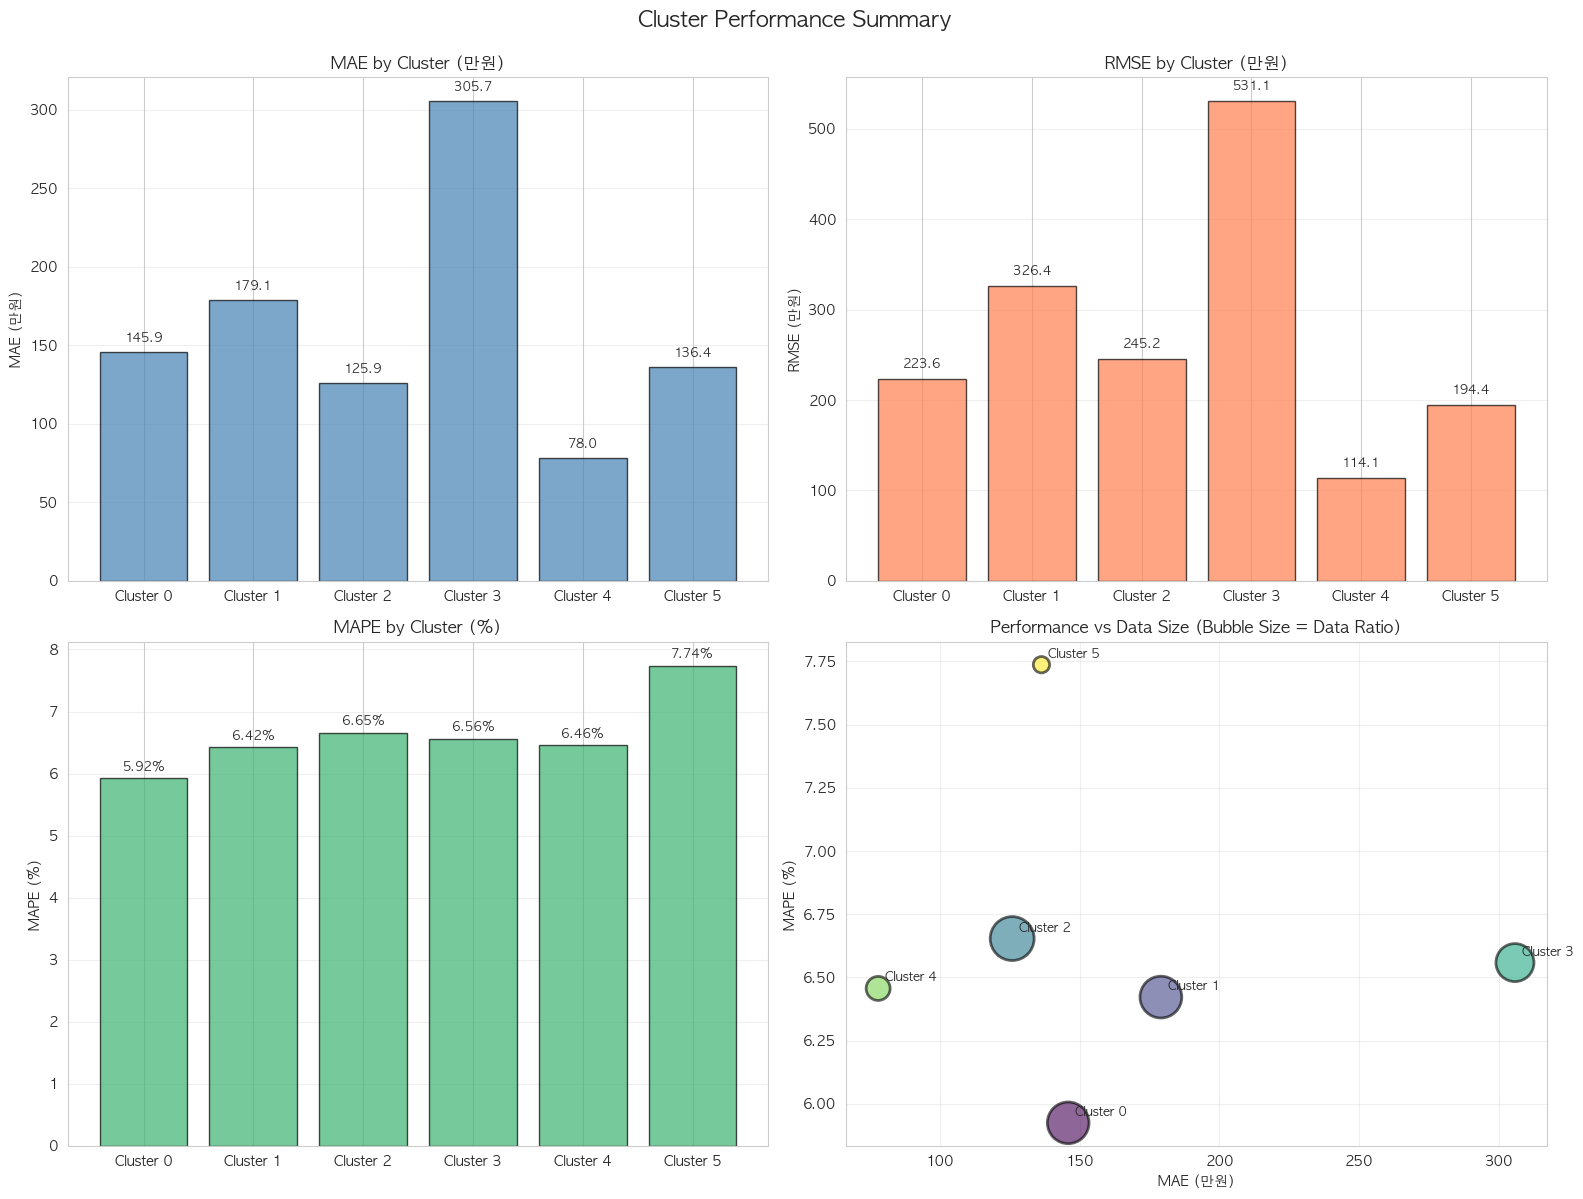

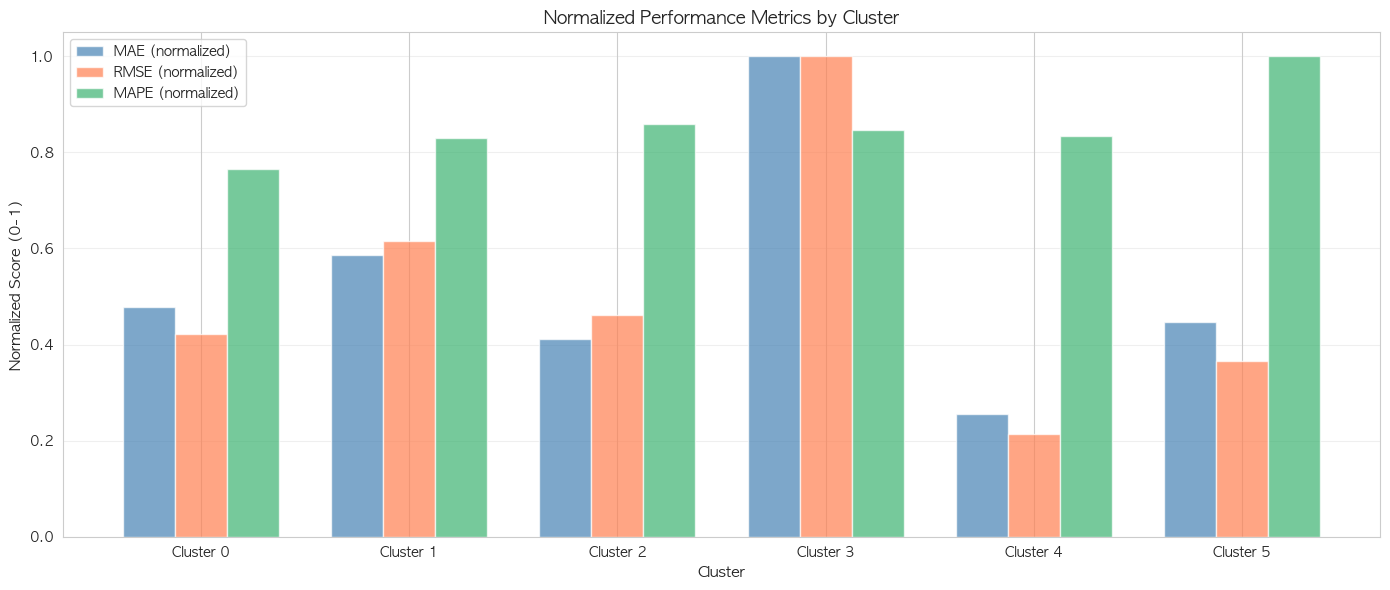

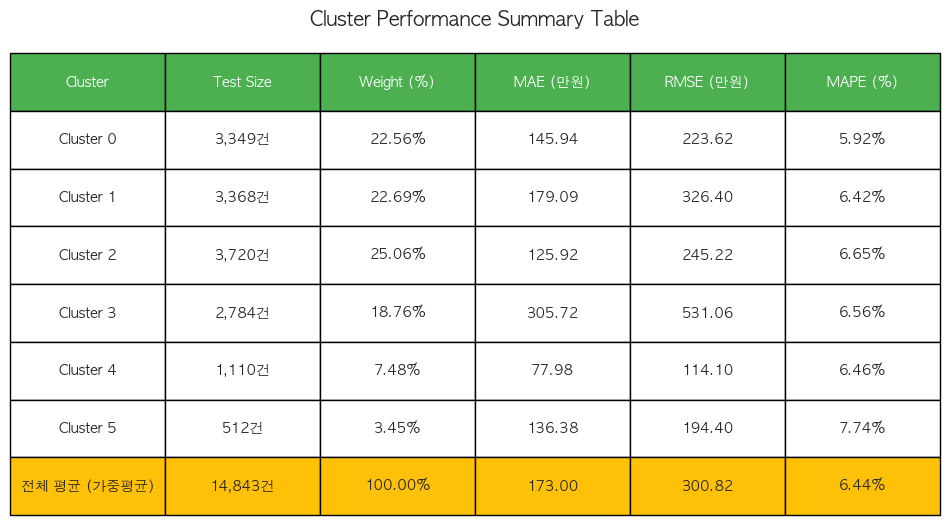


✓ 모든 시각화 완료!


In [ ]:


# 한글 폰트 설정 함수
def set_korean_font():
    """한글 폰트를 설정하는 함수"""
    import matplotlib.font_manager as fm
    try:
        # macOS에서 사용 가능한 한글 폰트 찾기
        font_list = [f.name for f in fm.fontManager.ttflist]
        korean_fonts = ['AppleGothic', 'NanumGothic', 'NanumBarunGothic', 'Malgun Gothic', 'Noto Sans CJK KR']
        korean_font = None
        for font in korean_fonts:
            if font in font_list:
                korean_font = font
                break
        
        if korean_font:
            plt.rcParams['font.family'] = korean_font
            return korean_font
        else:
            plt.rcParams['font.family'] = 'DejaVu Sans'
            return None
    except Exception as e:
        print(f"⚠ 폰트 설정 중 오류: {e}")
        plt.rcParams['font.family'] = 'DejaVu Sans'
        return None

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 중요: sns.set_style() 이후에 폰트를 다시 설정해야 함
korean_font = set_korean_font()
if korean_font:
    print(f"✓ 한글 폰트 설정 완료: {korean_font}")
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 클러스터별 성능 지표 비교 (Bar Plot)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cluster Performance Summary', fontsize=16, fontweight='bold', y=0.995)

# 1-1. MAE 비교
ax1 = axes[0, 0]
mae_values = [test_results[cluster_num]['mae'] for cluster_num in sorted(test_results.keys())]
cluster_labels = [f'Cluster {i}' for i in sorted(test_results.keys())]
bars1 = ax1.bar(cluster_labels, mae_values, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('MAE by Cluster (만원)', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAE (만원)', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
# 값 표시
for i, (bar, val) in enumerate(zip(bars1, mae_values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 1-2. RMSE 비교
ax2 = axes[0, 1]
rmse_values = [test_results[cluster_num]['rmse'] for cluster_num in sorted(test_results.keys())]
bars2 = ax2.bar(cluster_labels, rmse_values, color='coral', alpha=0.7, edgecolor='black')
ax2.set_title('RMSE by Cluster (만원)', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE (만원)', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
# 값 표시
for i, (bar, val) in enumerate(zip(bars2, rmse_values)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 1-3. MAPE 비교
ax3 = axes[1, 0]
mape_values = [test_results[cluster_num]['mape'] for cluster_num in sorted(test_results.keys())]
bars3 = ax3.bar(cluster_labels, mape_values, color='mediumseagreen', alpha=0.7, edgecolor='black')
ax3.set_title('MAPE by Cluster (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('MAPE (%)', fontsize=10)
ax3.grid(axis='y', alpha=0.3)
# 값 표시
for i, (bar, val) in enumerate(zip(bars3, mape_values)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 1-4. 클러스터별 데이터 비율과 성능 (Bubble Chart)
ax4 = axes[1, 1]
# 데이터 비율 계산
cluster_sizes = [cluster_weights.get(cluster_num, 0) for cluster_num in sorted(test_results.keys())]
size_normalized = [size / max(cluster_sizes) * 1000 for size in cluster_sizes]  # 버블 크기 정규화

scatter = ax4.scatter(mae_values, mape_values, s=size_normalized, 
                      c=range(len(cluster_labels)), cmap='viridis', 
                      alpha=0.6, edgecolors='black', linewidth=2)
ax4.set_xlabel('MAE (만원)', fontsize=10)
ax4.set_ylabel('MAPE (%)', fontsize=10)
ax4.set_title('Performance vs Data Size (Bubble Size = Data Ratio)', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

# 클러스터 라벨 추가
for i, (cluster, mae, mape) in enumerate(zip(cluster_labels, mae_values, mape_values)):
    ax4.annotate(cluster, (mae, mape), xytext=(5, 5), textcoords='offset points', 
                 fontsize=9, fontweight='bold')

plt.tight_layout()
# 저장 전에 폰트 다시 확인
set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
# 저장 주석 처리 (한글 깨짐 방지 - 필요시 주석 해제)
# plt.savefig(os.path.join(results_dir, 'cluster_performance_summary.png'), dpi=300, bbox_inches='tight')
# print(f"✓ 성능 요약 플롯 저장 완료: {os.path.join(results_dir, 'cluster_performance_summary.png')}")
plt.show()

# 2. 클러스터별 성능 비교 (Grouped Bar Chart)
fig2, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(cluster_labels))
width = 0.25

# MAE, RMSE, MAPE를 정규화하여 함께 비교 (0-1 스케일)
mae_norm = np.array(mae_values) / max(mae_values)
rmse_norm = np.array(rmse_values) / max(rmse_values)
mape_norm = np.array(mape_values) / max(mape_values)

bars1 = ax.bar(x - width, mae_norm, width, label='MAE (normalized)', color='steelblue', alpha=0.7)
bars2 = ax.bar(x, rmse_norm, width, label='RMSE (normalized)', color='coral', alpha=0.7)
bars3 = ax.bar(x + width, mape_norm, width, label='MAPE (normalized)', color='mediumseagreen', alpha=0.7)

ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Score (0-1)', fontsize=11)
ax.set_title('Normalized Performance Metrics by Cluster', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(cluster_labels)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# 저장 전에 폰트 다시 확인
set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
# 저장 주석 처리 (한글 깨짐 방지 - 필요시 주석 해제)
# plt.savefig(os.path.join(results_dir, 'cluster_performance_normalized.png'), dpi=300, bbox_inches='tight')
# print(f"✓ 정규화 성능 비교 플롯 저장 완료: {os.path.join(results_dir, 'cluster_performance_normalized.png')}")
plt.show()

# 3. 성능 요약 테이블 시각화
fig3, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# 테이블 데이터 준비
table_data = []
for cluster_num in sorted(test_results.keys()):
    result = test_results[cluster_num]
    weight_pct = (cluster_weights.get(cluster_num, 0) / total_test_size) * 100 if total_test_size > 0 else 0
    table_data.append([
        f'Cluster {cluster_num}',
        f"{cluster_weights.get(cluster_num, 0):,}건",
        f"{weight_pct:.2f}%",
        f"{result['mae']:.2f}",
        f"{result['rmse']:.2f}",
        f"{result['mape']:.2f}%"
    ])

# 전체 평균 행 추가
table_data.append([
    '전체 평균 (가중평균)',
    f"{total_test_size:,}건",
    "100.00%",
    f"{weighted_mae:.2f}",
    f"{weighted_rmse:.2f}",
    f"{weighted_mape:.2f}%"
])

table = ax.table(cellText=table_data,
                 colLabels=['Cluster', 'Test Size', 'Weight (%)', 'MAE (만원)', 'RMSE (만원)', 'MAPE (%)'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# 헤더 스타일
for i in range(6):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# 전체 평균 행 스타일
for i in range(6):
    table[(len(table_data), i)].set_facecolor('#FFC107')
    table[(len(table_data), i)].set_text_props(weight='bold')

plt.title('Cluster Performance Summary Table', fontsize=14, fontweight='bold', pad=20)
# 저장 전에 폰트 다시 확인
set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
# 저장 주석 처리 (한글 깨짐 방지 - 필요시 주석 해제)
# plt.savefig(os.path.join(results_dir, 'cluster_performance_table.png'), dpi=300, bbox_inches='tight')
# print(f"✓ 성능 요약 테이블 저장 완료: {os.path.join(results_dir, 'cluster_performance_table.png')}")
plt.show()

print("\n✓ 모든 시각화 완료!")


In [ ]:
# ============================================================
# 모델 저장 (Streamlit용)
# ============================================================
import os
import json

# 프로젝트 루트가 설정되어 있지 않으면 설정
if 'project_root' not in globals():
    current_dir = os.getcwd()
    if '03_배포용' in current_dir:
        project_root = current_dir.split('03_배포용')[0]
    else:
        project_root = current_dir
        while not os.path.exists(os.path.join(project_root, '03_배포용')):
            parent = os.path.dirname(project_root)
            if parent == project_root:
                project_root = os.getcwd()
                break
            project_root = parent

models_dir = os.path.join(project_root, '03_배포용/00_data/03_result/lgbm_models/saved_models')
os.makedirs(models_dir, exist_ok=True)

print("="*70)
print("모델 저장 (Streamlit 배포용)")
print("="*70)

# 1. LightGBM 모델들 저장
if 'models' in globals() and models:
    for cluster_num, model in models.items():
        model_path = os.path.join(models_dir, f'lgbm_model_cluster_{cluster_num}.txt')
        model.save_model(model_path)
        print(f"✓ Cluster {cluster_num} 모델 저장: {model_path}")
    print(f"\n✓ 총 {len(models)}개 모델 저장 완료")
else:
    print("⚠ 'models' 딕셔너리가 없습니다. 먼저 모델을 학습하세요.")

# 2. 최적 파라미터 저장 (이미 저장되어 있지만 확인)
if 'best_params' in globals() and best_params:
    params_file = os.path.join(models_dir, 'best_params.json')
    
    # JSON 직렬화를 위해 키를 문자열로, 값들을 Python 기본 타입으로 변환
    import numpy as np
    params_to_save = {}
    for key, value in best_params.items():
        # 키를 문자열로 변환
        str_key = str(key)
        # 값이 딕셔너리인 경우 (클러스터별 파라미터)
        if isinstance(value, dict):
            params_to_save[str_key] = {}
            for param_key, param_value in value.items():
                # numpy 타입을 Python 기본 타입으로 변환
                if isinstance(param_value, (np.integer, np.int64, np.int32)):
                    params_to_save[str_key][param_key] = int(param_value)
                elif isinstance(param_value, (np.floating, np.float64, np.float32)):
                    params_to_save[str_key][param_key] = float(param_value)
                elif isinstance(param_value, np.bool_):
                    params_to_save[str_key][param_key] = bool(param_value)
                else:
                    params_to_save[str_key][param_key] = param_value
        else:
            # 값이 단일 값인 경우
            if isinstance(value, (np.integer, np.int64, np.int32)):
                params_to_save[str_key] = int(value)
            elif isinstance(value, (np.floating, np.float64, np.float32)):
                params_to_save[str_key] = float(value)
            elif isinstance(value, np.bool_):
                params_to_save[str_key] = bool(value)
            else:
                params_to_save[str_key] = value
    
    with open(params_file, 'w', encoding='utf-8') as f:
        json.dump(params_to_save, f, indent=2, ensure_ascii=False)
    print(f"✓ 최적 파라미터 저장: {params_file}")
else:
    print("⚠ 'best_params' 딕셔너리가 없습니다.")

# 3. 선택된 피처 저장 (Feature Selection 삭제됨 - 더 이상 사용하지 않음)

print("\n" + "="*70)
print("✓ 모델 저장 완료! Streamlit 앱에서 사용할 수 있습니다.")
print("="*70)


모델 저장 (Streamlit 배포용)
✓ Cluster 0 모델 저장: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_0.txt
✓ Cluster 1 모델 저장: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_1.txt
✓ Cluster 2 모델 저장: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_2.txt
✓ Cluster 3 모델 저장: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_3.txt
✓ Cluster 4 모델 저장: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_4.txt
✓ Cluster 5 모델 저장: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_5.txt

✓ 총 6개 모델 저장 완료
✓ 최적 파라미터 저장: ../03_results/lgbm_models/saved_models/best_params.json

✓ 모델 저장 완료! Streamlit 앱에서 사용할 수 있습니다.


저장된 모델 불러오기 및 예측 테스트
✓ Cluster 0 모델 로드 성공: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_0.txt
  - 트리 수: 1000
✓ Cluster 1 모델 로드 성공: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_1.txt
  - 트리 수: 1000
✓ Cluster 2 모델 로드 성공: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_2.txt
  - 트리 수: 1000
✓ Cluster 3 모델 로드 성공: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_3.txt
  - 트리 수: 1000
✓ Cluster 4 모델 로드 성공: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_4.txt
  - 트리 수: 1000
✓ Cluster 5 모델 로드 성공: ../03_results/lgbm_models/saved_models/lgbm_model_cluster_5.txt
  - 트리 수: 1000

✓ 총 6개 모델 로드 완료

✓ 최적 파라미터 로드 성공: ../03_results/lgbm_models/saved_models/best_params.json
  - 클러스터 수: 6개

예측 함수 정의 완료

사용 예시:
  # 감가율 예측
  depreciation = predict_depreciation_rate(cluster_num=0, X_data=X_test)
  
  # 판매가 예측
  sale_price, depreciation = predict_sale_price(
      cluster_num=0, X_data=X_test, new_price=df_test['신차가격(선택옵션포함)'])

Test 데이터로 예측 테스트

Cluster 0